# Notebook 8: smoothing selection and forward sensitivity

This notebook selects smoothing from noisy held-out quotes and evaluates the complete rule separately. It then stresses supplied forwards while preserving physical risk thresholds. The executed cell verifies and reuses matching saved cases. A fresh run can take tens of minutes: use `python run_selection.py --fresh --workers 4` from the project folder, then rebuild this notebook. Run `python build_milestone8_notebook.py` to refresh computed text, tables and embedded figures together.


In [1]:
from run_selection import main
from build_selection_report import main as build_report
result = main(resume=True, workers=4)
build_report()


Selection: 80 saved / 80 planned experiments; 0 to run.
Forward: 160 saved / 160 planned experiments; 0 to run.
1000 unique accepted joint fits; 0 failed/blocked experiments; minimum calendar gap -9.996e-10.
Generated Figures 21–23 and Tables 18–21 from the complete saved study.


# Selecting smoothing and testing the supplied forward

## 1. Research question and scope

The previous notebooks held the smoothing coefficient fixed while measuring recovery error. This notebook asks whether selecting that coefficient from noisy observed prices improves subsequent recovery, and how the fitted result changes when the supplied forward is wrong. These are separate questions: the first changes the selection rule; the second perturbs a required input while holding the selected coefficient fixed.

As Cawley and Talbot explain in *On Over-fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation*, choosing a model and assessing its performance are distinct parts of an evaluation procedure [17, §§2.1, 5.1]. Here, selection uses noisy quotes alone. Known synthetic prices at separate strikes, densities and tail probabilities are reserved for evaluation. The selector is rerun in every repetition. This is a fixed-design simulation, not a historical market forecast or a claim that cross-validation identifies the true density.

The two benchmark families, eight horizons, 120 density bins and interval-level calendar checks remain those of Notebooks 6–7. The experiment uses Original 81 and Extended 121 quote patterns, the bounded errors in Equation (26) with $a=0.5$ index points, and 20 new random realisations per benchmark/pattern. Within each repetition, both patterns and benchmark families share the master random draws. New child streams distinguish this study from Notebook 7. A runtime/feasibility pilot was completed before the full batch; the fixed repetition count was retained, and no early stopping rule depends on favourable results.

## 2. Selecting one coefficient for all maturities

As Boyd and Vandenberghe discuss in *Convex Optimization*, a regularisation term balances fit against a chosen notion of complexity [11, §6.3]. Our existing quadratic objective supplies that balance through Equation (12). The candidate set is deliberately small: $\Lambda=\{10^{-7},10^{-6},10^{-5}\}$, corresponding to the earlier 0.1×, 1× and 10× baseline values at unchanged bin width. The experiment evaluates this finite rule; it does not search continuously for an optimum.

For each quote pattern, the ordered interior strikes are assigned in turn to three folds. Both endpoint quotes remain in every training set, retaining the observed span. Each interior quote is held out exactly once. Original 81 has 27, 26 and 26 held-out quotes per maturity; Extended 121 has 40, 40 and 39. The same fold positions are used at each maturity. All eight maturities are fitted jointly for every candidate and fold, using only that fold's training quotes.

Let $\mathcal H_k$ contain the quote positions held out in fold $k$, and let $\widehat C_{m,\lambda}^{(-k)}$ denote the resulting training-only call fit. The pooled criterion is

$$
\operatorname{CV}(\lambda)=
\frac{\displaystyle\sum_{k=1}^{3}\sum_{m=1}^{M}\sum_{i\in\mathcal H_k}
\left[\frac{\widehat C_{m,\lambda}^{(-k)}(K_{mi})-y_{mi}}{F_m}\right]^2}
{\displaystyle M\sum_{k=1}^{3}|\mathcal H_k|},
\qquad
\widehat\lambda=\max\!\left(\operatorname*{arg\,min}_{\lambda\in\Lambda}\operatorname{CV}(\lambda)\right).
\tag{30}
$$

The maximum resolves exact score ties in favour of stronger smoothing; no numerical tie band or one-standard-error rule is used. Pooling individual errors gives each held-out observation equal weight after forward scaling. Averaging the three fold means equally would instead overweight the smaller folds. Scaling by $F_m$ matches the price-loss convention of Equation (12); it is not division by the discount factor or inverse weighting by the noise variance.

The endpoints are excluded from the validation score, and the fitted training grids are thinner than the final grid. These deliberate choices make this an interior-price interpolation rule. It does not directly target unobserved tails, recover omitted wings or estimate the best coefficient for a full grid without approximation. Selection takes place within each quote pattern: the patterns' different spans and error variances mean that their absolute CV scores do not share an identical validation target. Three dependent folds also do not supply three independent repetitions: uncertainty is measured across the 20 separately generated quote realisations.

The selected coefficient is then used to refit all observations. A full-data fit with the fixed baseline $\lambda=10^{-6}$ is the paired control, using exactly the same quotes and numerical settings. When selection chooses the baseline, that fit is reused and the comparison is exactly zero. Clean-price errors, full-domain density errors and risk summaries are calculated only after selection and both full-data fits have been fixed. The final price grid contains the same 120 arithmetic master-strike midpoints per maturity as Notebook 7: 960 prices, none supplied to a fit. With Original 81, that common test grid includes extrapolation; with Extended 121, it lies within the observed span.

**Table 18.** Smoothing selections in 20 repetitions per benchmark and strike pattern. All columns refer to the declared candidate set; selecting an endpoint does not establish that it is optimal beyond this set.

| Benchmark | Strike pattern | Selected 10⁻⁷ | Selected 10⁻⁶ | Selected 10⁻⁵ |
|---|---|---:|---:|---:|
| Single lognormal | Original 81 | 0 | 20 | 0 |
| Single lognormal | Extended 121 | 0 | 20 | 0 |
| Two-lognormal mixture | Original 81 | 20 | 0 | 0 |
| Two-lognormal mixture | Extended 121 | 20 | 0 | 0 |



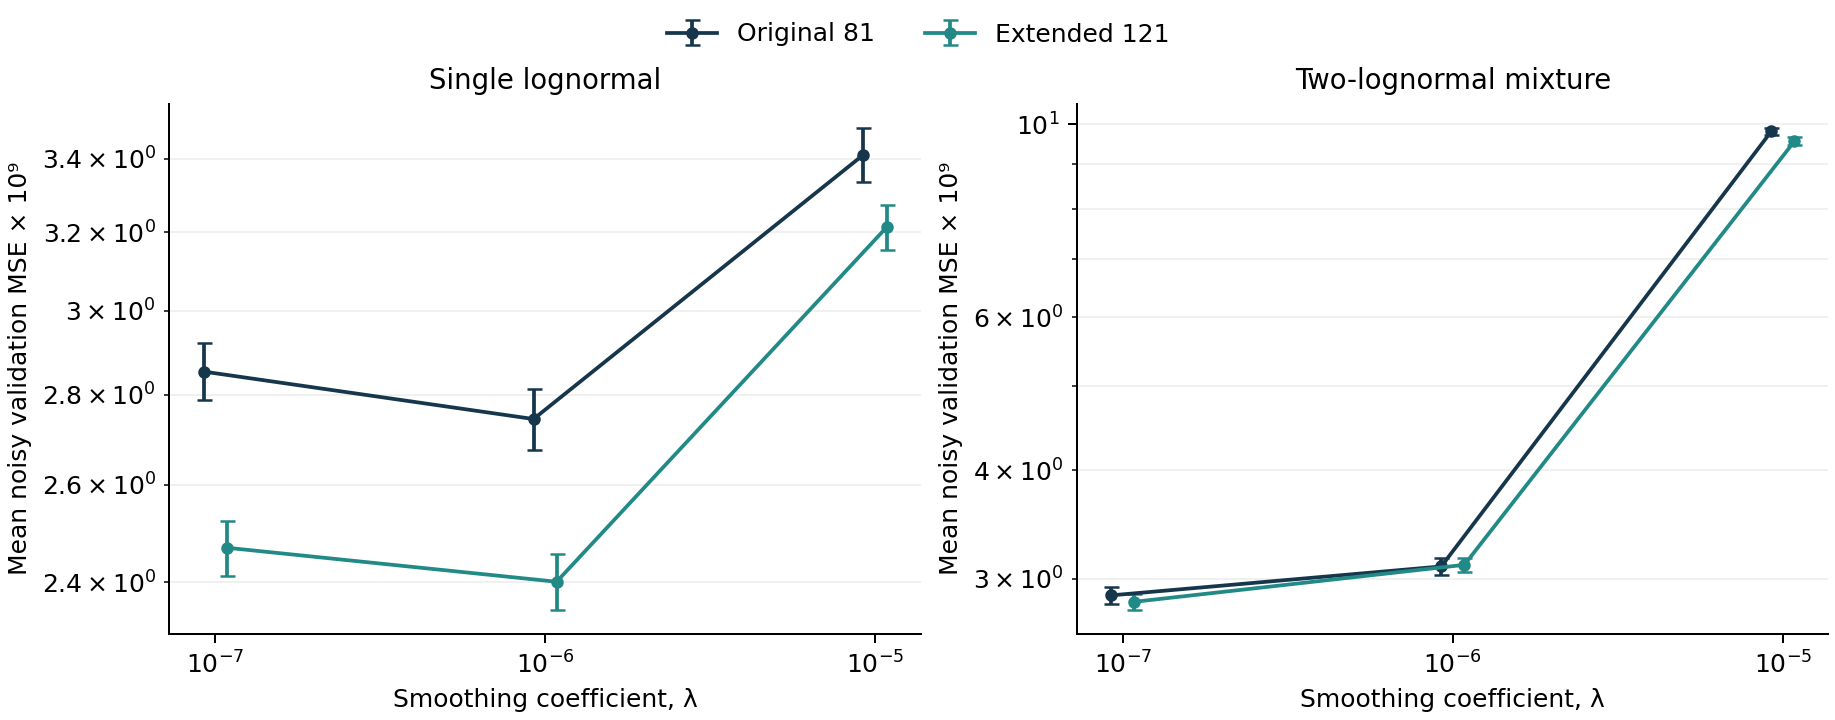




Figure 21. Mean pooled noisy-price validation MSE for each smoothing coefficient, with ±2 Monte Carlo standard errors across the 20 repetitions. The dimensionless score is multiplied by $10^9$ for display and the vertical scale is logarithmic. Lines connect the three evaluated candidates. These scores select the coefficient; they are not the final recovery-performance estimates.

Across 80 selection experiments, the three candidates were chosen 40, 40 and 0 times, respectively. The lower candidate was selected in 40 experiments; those choices establish only a preference within the declared grid. The grid was not extended after examining evaluation results. Table 18 also retains cases where the rule simply confirms the baseline.

## 3. Evaluating the complete selection rule

As Morris, White and Crowther discuss in *Using simulation studies to evaluate statistical methods*, finite simulation summaries have their own Monte Carlo uncertainty [16, §§5.2–5.4]. Tables 19–21 therefore show a mean followed by its MCSE in parentheses. Equation (29) is applied to within-repetition differences for Table 20. These MCSEs describe the declared experiment, not confidence intervals for a market distribution. All 20 planned repetitions must succeed before a group's performance is reported.

**Table 19.** Recovery after full-data refitting. The clean-price RMSE pools 960 withheld prices in each repetition. Full-density $L_1$ is averaged across eight maturities and includes the known omitted tails as in Equation (23). Upper-tail bias is the mean error in $Q(S_T>1.8F)$ at 365 days, expressed in percentage points. Entries are mean (MCSE).

| Benchmark | Pattern | Rule | Clean-price RMSE (points) | Full-density L1 | 365-day upper-tail bias (pp) |
|---|---|---|---:|---:|---:|
| Single lognormal | Original 81 | Fixed 10⁻⁶ | 0.2178 (0.0107) | 0.0358 (0.0001) | -0.0374 (0.0099) |
| Single lognormal | Original 81 | Selected | 0.2178 (0.0107) | 0.0358 (0.0001) | -0.0374 (0.0099) |
| Single lognormal | Extended 121 | Fixed 10⁻⁶ | 0.0948 (0.0012) | 0.0336 (0.0001) | +0.0080 (0.0066) |
| Single lognormal | Extended 121 | Selected | 0.0948 (0.0012) | 0.0336 (0.0001) | +0.0080 (0.0066) |
| Two-lognormal mixture | Original 81 | Fixed 10⁻⁶ | 0.8887 (0.0434) | 0.0574 (0.0004) | +0.3225 (0.0530) |
| Two-lognormal mixture | Original 81 | Selected | 1.0928 (0.0290) | 0.0704 (0.0009) | +0.2533 (0.0511) |
| Two-lognormal mixture | Extended 121 | Fixed 10⁻⁶ | 0.1587 (0.0015) | 0.0524 (0.0003) | -0.0358 (0.0073) |
| Two-lognormal mixture | Extended 121 | Selected | 0.1174 (0.0011) | 0.0630 (0.0003) | -0.0366 (0.0110) |



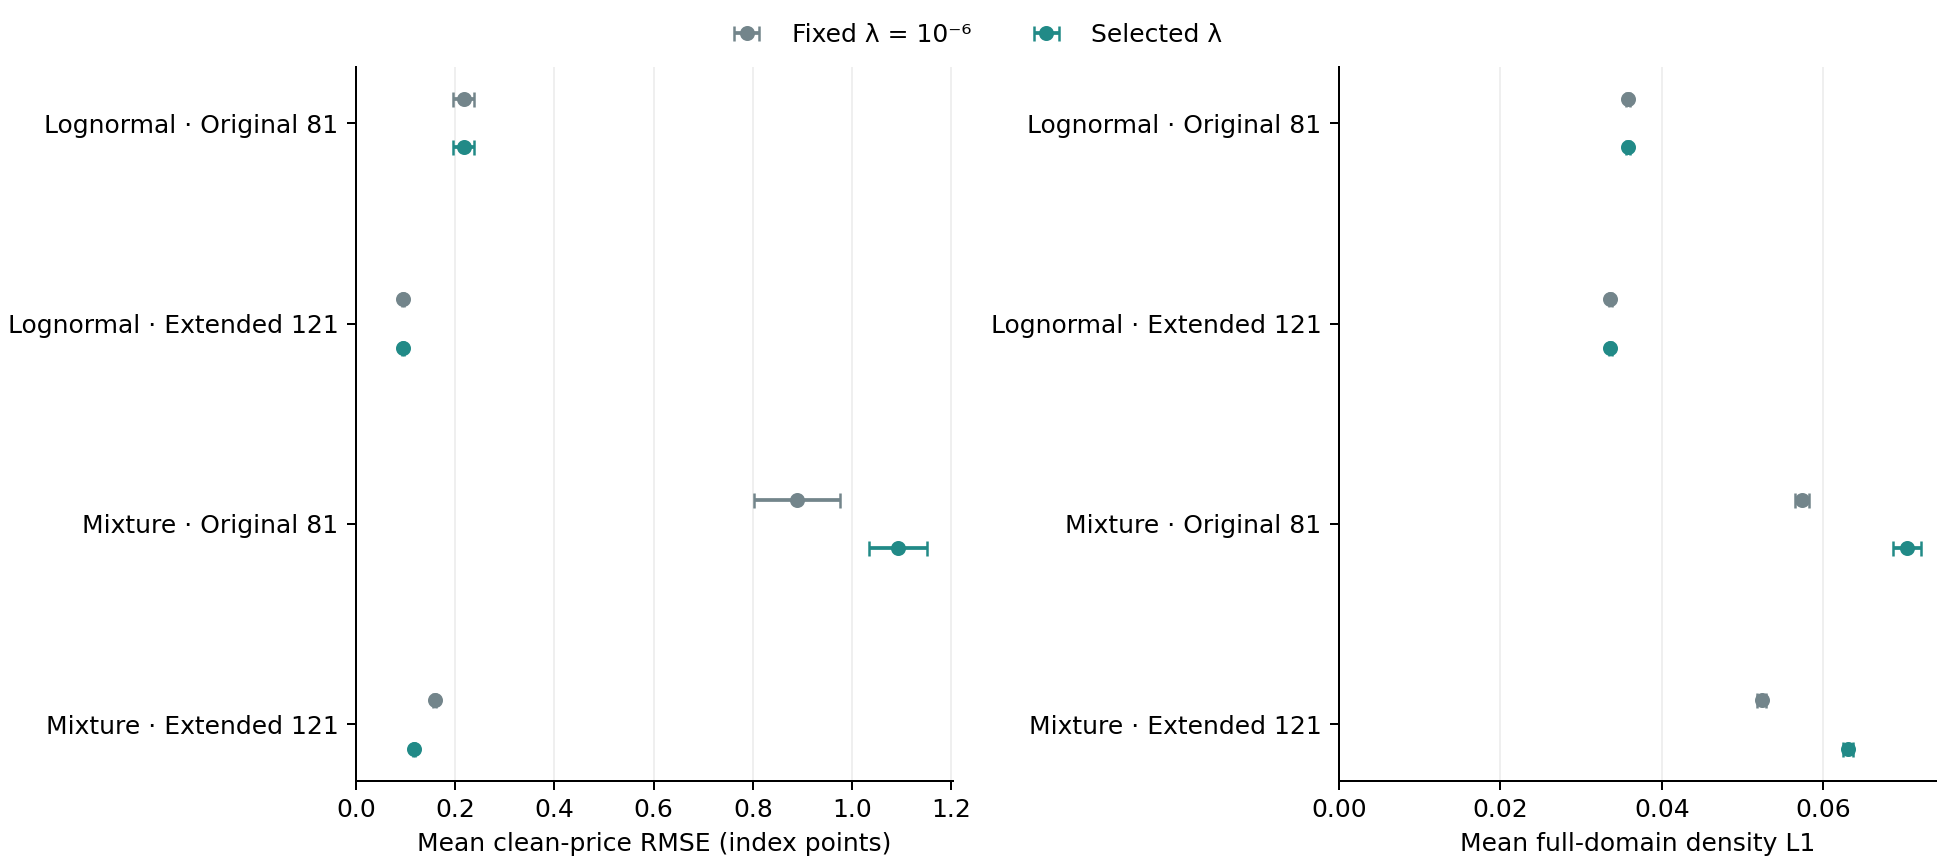




Figure 22. Mean clean-price RMSE and full-domain density error after refitting with selected or fixed smoothing, using the same quote realisations in each comparison. Bars show ±2 MCSE. A small price error does not, by itself, establish a small density error, since prices integrate the density through the payoff relationship in Equation (1).

**Table 20.** Paired selected-minus-fixed differences, reported as mean (MCSE). Negative values indicate lower error under the selection rule. The last column compares absolute errors for the fixed 365-day upper-tail event; it is not a difference between signed biases.

| Benchmark | Pattern | Δ clean-price RMSE (points) | Δ full-density L1 | Δ absolute upper-tail error (pp) |
|---|---|---:|---:|---:|
| Single lognormal | Original 81 | +0.0000 (0.0000) | +0.0000 (0.0000) | +0.0000 (0.0000) |
| Single lognormal | Extended 121 | +0.0000 (0.0000) | +0.0000 (0.0000) | +0.0000 (0.0000) |
| Two-lognormal mixture | Original 81 | +0.2042 (0.0374) | +0.0130 (0.0007) | -0.0692 (0.0316) |
| Two-lognormal mixture | Extended 121 | -0.0413 (0.0011) | +0.0107 (0.0004) | +0.0073 (0.0048) |

For the mixture under Original 81, mean clean-price RMSE changes from 0.8887 to 1.0928 points, while mean full-density error changes from 0.0574 to 0.0704. The paired density-error change is +0.0130 (MCSE 0.0007).

For the mixture under Extended 121, mean clean-price RMSE changes from 0.1587 to 0.1174 points, while mean full-density error changes from 0.0524 to 0.0630. The paired density-error change is +0.0107 (MCSE 0.0004).

These comparisons concern this selection rule and these benchmark families. They do not establish that the smallest price-validation score minimises density or tail error. The signed and absolute tail comparisons in Tables 19–20 must be read separately.

A **post-hoc range diagnostic**, added after the Original 81 mixture discrepancy was observed, locates the price deterioration. At the 640 clean test strikes inside the observed range, mean RMSE changes from 0.1571 to 0.1235 points; at the 320 outside it, the error changes from 1.5224 to 1.8847 points. The paired outside-range change is +0.3623 (MCSE 0.0653). Thus improved interior interpolation accompanies worse extrapolation on the declared common grid. This diagnostic reuses the saved fits and changes neither the chosen coefficients nor the primary measures. It is an explanation of the observed result, not a newly tuned performance claim.

## 4. Perturbing the forward without changing the event

As Bahra explains in his Bank of England research paper, the risk-neutral valuation framework links the terminal mean to the forward under the stated assumptions [1, §2.1 and Mathematical appendix]. Equation (10) therefore enforces the supplied forward as an input. Meeting that constraint cannot establish that the input is correct.

The forward stress uses Extended 121, both benchmark families and the same 20 realisations. For every maturity, it supplies

$$
\widetilde F_m^{(\varepsilon)}=(1+\varepsilon)F_m,
\qquad
\varepsilon\in\{-0.005,-0.001,0,0.001,0.005\}.
\tag{31}
$$

These are declared ±0.5% and ±0.1% stresses, not estimated error probabilities or empirically calibrated forward uncertainty. Option strikes, observed prices, discounts and maturity times stay fixed. Each repetition retains the coefficient selected at the correct forward. Thus the study measures conditional sensitivity to forward inputs; it does not evaluate reselecting smoothing under an incorrect forward.

The support stays $[0.3,2.2]$ in supplied-forward coordinates. Its physical endpoints therefore move with $\widetilde F_m$. The fitted mean, normalised price loss, density roughness and calendar normalisation also use that supplied forward. These consequences are part of this estimator's response to changing its input, not separately isolated causal effects.

For evaluation, all fitted distributions must be expressed relative to the same known reference forward. In particular,

$$
\widehat g_m^{(\varepsilon),\mathrm{ref}}(x)
=F_m\widehat f_m^{(\varepsilon)}(F_m x),
\qquad
\widehat p_{1.8,m}^{(\varepsilon)}
=\int_{1.8}^{\infty}\widehat g_m^{(\varepsilon),\mathrm{ref}}(x)\,\mathrm dx.
\tag{32}
$$

The event remains $S_T>1.8F_m$, even when the supplied forward changes. The lower 0.8 and upper 1.2 thresholds are treated identically. In the code, the evaluation copy retains the fitted physical bin edges and probabilities and changes only the reference used to interpret them. It does not move, refit or renormalise the distribution. Independent uniform-distribution and physical-integration checks verify this conversion. The normalised variance remains centred at the fitted mean. The fitted mean relative to the reference forward is approximately $1+\varepsilon$ by construction, so it is not reported as an independent accuracy success.

Gatheral and Jacquier's martingale/convexity argument motivates the calendar ordering used here [12, §2.1]. In this stress experiment, passing that numerical check is conditional on the supplied forward curve. It does not verify the benchmark's correct curve, nor does it establish accuracy of the recovered density.

## 5. A diagnostic for incompatible forward inputs

The discounted expected-payoff relationship described by Bahra [1] also implies a useful lower bound. For a nonnegative, unit-mass distribution with mean $\widetilde F_m$, convexity of the positive-part payoff gives

$$
C_m(K_{mi})\geq L_{mi}^{(\varepsilon)}
=D_m\bigl(\widetilde F_m^{(\varepsilon)}-K_{mi}\bigr)_+,
\qquad
v_{mi}^{(\varepsilon)}=\bigl(L_{mi}^{(\varepsilon)}-y_{mi}\bigr)_+.
\tag{33}
$$

This is a project derivation from Equation (1), not a new pricing relationship attributed verbatim to a source. We record the number of quotes with shortfall $v>10^{-10}$ points, the maximum shortfall and its root mean square. The RMS shortfall is a theoretical lower bound on RMS fitting error at the observed quotes under exact probability constraints. It is distinct from the clean-price RMSE at the separate test strikes. No quotes are clipped or replaced. The bounded noise in Equation (26) prevents negative call prices but does not enforce this intrinsic-value bound; some zero-shift observations can therefore fail it too.

**Table 21.** Forward stress with the selected zero-shift coefficient held fixed. Entries are mean (MCSE); all errors use the same benchmark and physical risk events. The last column counts supplied-forward lower-bound violations among the 968 observed calls in each repetition. It diagnoses incompatible inputs, rather than failed solver convergence.

| Benchmark | Forward error (%) | Clean-price RMSE (points) | Full-density L1 | Upper-tail bias (pp) | Quotes below lower bound / 968 |
|---|---:|---:|---:|---:|---:|
| Single lognormal | -0.5 | 2.9202 (0.0001) | 0.0829 (0.0001) | +0.0082 (0.0066) | 0.00 (0.00) |
| Single lognormal | -0.1 | 0.4770 (0.0002) | 0.0421 (0.0001) | +0.0080 (0.0067) | 0.00 (0.00) |
| Single lognormal | +0.0 | 0.0948 (0.0012) | 0.0336 (0.0001) | +0.0080 (0.0066) | 56.90 (1.05) |
| Single lognormal | +0.1 | 2.4965 (0.0001) | 0.0559 (0.0001) | +0.0080 (0.0066) | 216.90 (0.26) |
| Single lognormal | +0.5 | 14.3147 (4e-05) | 0.1637 (0.0002) | +0.0081 (0.0066) | 285.00 (0.00) |
| Two-lognormal mixture | -0.5 | 1.7653 (0.0001) | 0.1079 (0.0003) | -0.0413 (0.0085) | 0.00 (0.00) |
| Two-lognormal mixture | -0.1 | 0.2109 (0.0006) | 0.0726 (0.0003) | -0.0393 (0.0108) | 0.00 (0.00) |
| Two-lognormal mixture | +0.0 | 0.1174 (0.0011) | 0.0630 (0.0003) | -0.0366 (0.0110) | 0.05 (0.05) |
| Two-lognormal mixture | +0.1 | 1.0523 (0.0001) | 0.0823 (0.0004) | -0.0340 (0.0113) | 99.35 (0.28) |
| Two-lognormal mixture | +0.5 | 10.2713 (1.5e-05) | 0.1468 (0.0004) | -0.0239 (0.0131) | 227.30 (0.29) |



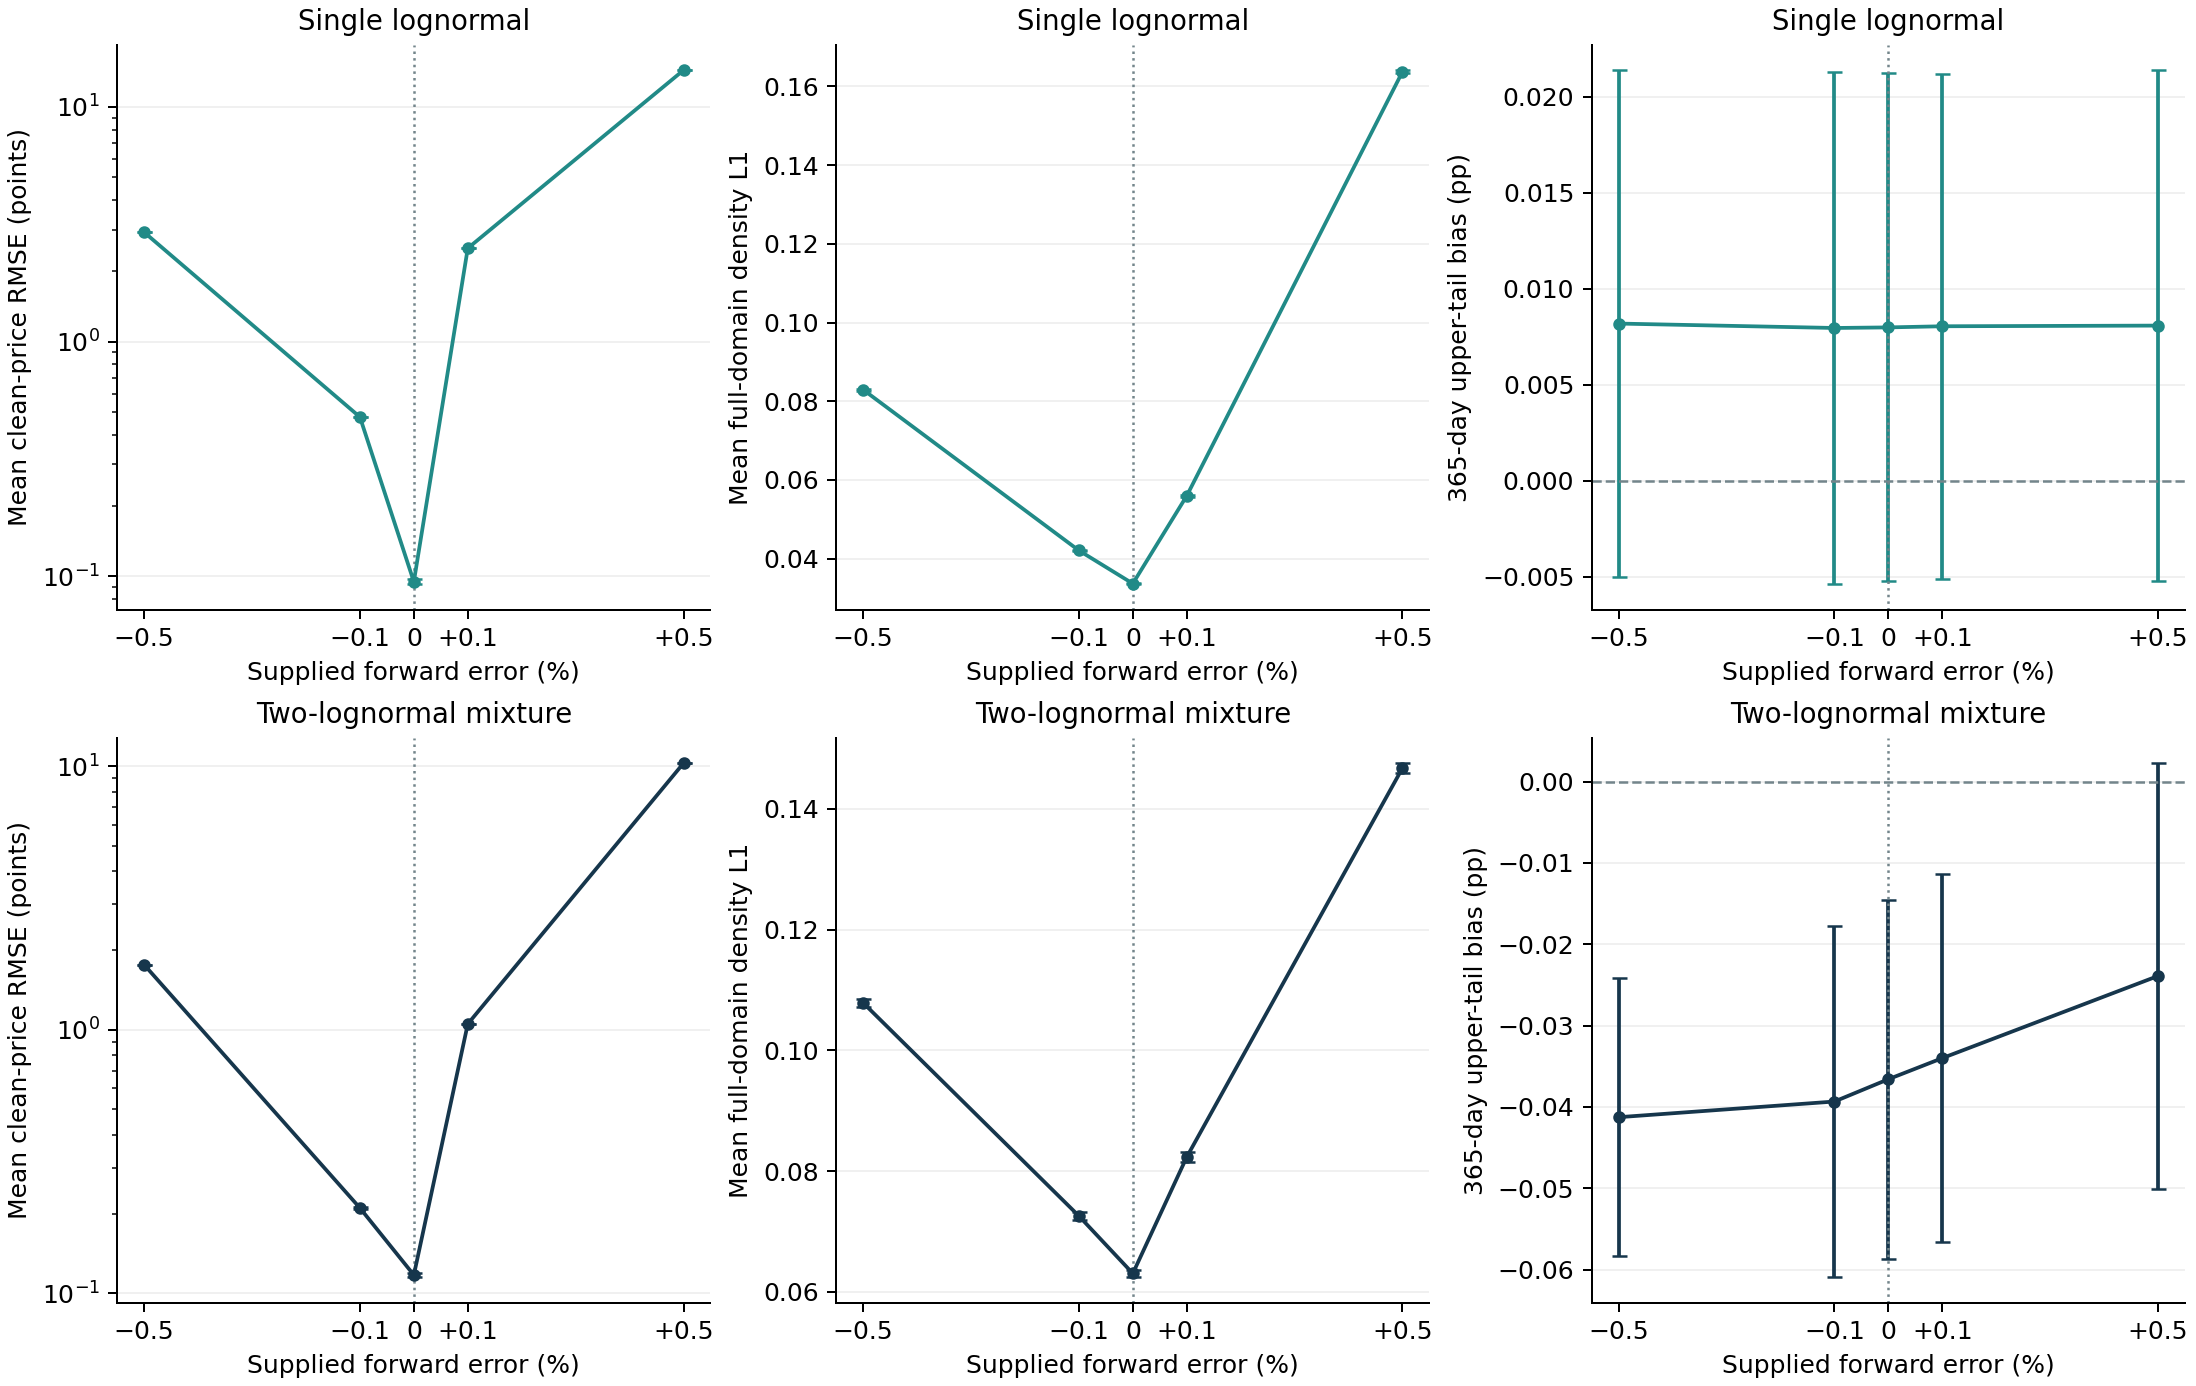




Figure 23. Sensitivity of the selected fit to the supplied forward, under Extended 121 coverage. Points are repetition means with ±2 MCSE; connecting lines are visual guides between the five stated stress levels. The price-error axis is logarithmic. The tail event remains $S_T>1.8F_{\mathrm{true}}$ at 365 days throughout. Calendar feasibility is checked separately in supplied-forward coordinates.

For the mixture, mean clean-price RMSE is 0.1174 points at the correct forward, 1.7653 at −0.5%, and 10.2713 at +0.5%. The positive stress puts an average of 227.3 of the 968 observed quotes below the supplied-forward lower bound. This diagnostic helps explain the asymmetric price response, but does not separate every effect of changing the forward. All five stress levels retain the same physical tail event; an apparent change cannot be attributed to silently moving the threshold. A tail metric can improve at one stress level while the overall density or price fit deteriorates, so it is not used alone to validate the supplied forward.

## 6. Numerical evidence, limitations and next stage

The completed study records 240 planned experiments: 80 smoothing selections and 160 nonzero forward stresses. Zero-shift results reuse the corresponding selected fits. There are **1,000 unique accepted joint fits and 8,000 marginal densities**, including the 720 training-only CV fits; 40 fixed-control fits are reused. There are 0 failed or blocked experiments. The worst final calendar gap is -9.996e-10, within the $10^{-8}$ acceptance tolerance. At most 7 refinement rounds and 40 solver iterations per round were needed. The minimum raw mass across all solver rounds is -9.477e-12; small signed numerical residuals are retained. No probability clipping or renormalisation is used. The largest density-quadrature refinement estimate is 1.997e-07. Successive-rule agreement is a numerical check, not a rigorous error bound.

The source-and-protocol fingerprint, complete random states, observed-price export, fold memberships, fold residuals, fitted probabilities and solver histories are retained. The forward cases identify the exact selected parent case. Matching completed cases can be reused; altered inputs, code, content or parent results are rejected. Numerical success is reported separately from price, density and tail errors. The figure exporter validates temporary PNG and SVG files before replacing their destinations, retaining the correction introduced after Notebook 7's artifact check.

This experiment retains idealised bounded independent quote errors, deterministic rates/dividends, two chosen benchmark families and fixed support/resolution. It evaluates only three candidate penalties and 20 new realisations. Its interlaced folds are suitable for the declared interpolation question; a historical validation design must respect observation dates and contemporaneous quote structure. No clean density target is available for selecting a coefficient in real market data, and no empirical SPX density is claimed here.

The working [project roadmap](research/project_roadmap.md) now has eight completed notebooks and two planned empirical stages, followed by assembly of the final paper. The remaining gate is verified quote provenance, timestamps, settlement horizons, usable bid/ask observations and justified discount/forward inputs. Existing offline 3D maturity explorers remain available; historical-date animation depends on verified observations across dates. The [development reflection](research/development_reflection.md) records this notebook's observed difficulties, decisions and remaining limitations.

## Sources and reproducibility

References use the [shared bibliography and source mapping](research/references.md). The substantive sources used here are Bahra [1] for valuation and the forward mean; Boyd and Vandenberghe [11] for regularisation; Gatheral and Jacquier [12] for calendar ordering; Goulart and Chen [15] for the Clarabel solver; Morris, White and Crowther [16] for simulation summaries; and Cawley and Talbot [17] for separating selection from evaluation. The fold arrangement, candidate grid, shock levels, thresholds and numerical findings are project choices or calculations, not results asserted by those papers.

Evidence: [declared protocol](results/selection_protocol.json), [feasibility pilot](results/selection_pilot.json), [complete numerical report](results/selection_validation.json), [post-hoc range diagnostic](results/selection_range_diagnostic.json), [observed inputs](results/selection_quotes.csv), [performance export](results/selection_metrics.csv), [independent checks](tests/test_selection.py), and the `results/selection_cases/` records.
